In [3]:
import pandas as pd
import numpy as np

import sys
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

project_root = os.path.abspath("..")   # Go up one level to CustomerRetentionAI
sys.path.insert(0, project_root)

from src.evaluation import evaluate_model

In [4]:
df = pd.read_csv("../data/processed/feature_engineered.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Build Processor

In [6]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=["number"]
).columns.tolist()

C:\Users\sansi\AppData\Local\Temp\ipykernel_24964\2825086182.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X_train.select_dtypes(


In [7]:
numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# Baseline - LR

In [8]:
baseline_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

baseline_pipeline.fit(X_train, y_train)

baseline_results = evaluate_model(
    "Baseline LR",
    baseline_pipeline,
    X_test,
    y_test
)


Baseline LR
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.53      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.78      0.79      0.79      1407



# Balanced - LR

In [9]:
balanced_lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        random_state=42,
        max_iter=1000
    ))
])

In [10]:
balanced_lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['gender','SeniorCitizen','Partner',...,'StreamingUser','AutoPayment', 'PremiumCustomer']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [11]:
balanced_lr_results = evaluate_model(
    "Balanced LR",
    balanced_lr_pipeline,
    X_test,
    y_test
)


Balanced LR
              precision    recall  f1-score   support

           0       0.90      0.71      0.79      1033
           1       0.49      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



# Balanced - RF

In [12]:
balanced_rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

In [13]:
balanced_rf_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](28,)","['gender','SeniorCitizen','Partner',...,'StreamingUser','AutoPayment', 'PremiumCustomer']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,28
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainde

In [14]:
balanced_rf_results = evaluate_model(
    "Balanced RF",
    balanced_rf_pipeline,
    X_test,
    y_test
)


Balanced RF
              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.54      0.63      0.58       374

    accuracy                           0.76      1407
   macro avg       0.70      0.72      0.71      1407
weighted avg       0.77      0.76      0.77      1407



# COMPare against SMOTE

In [15]:
smote_results = {
    "Model": "SMOTE LR",
    "Accuracy": 0.737740,
    "Precision": 0.504333,
    "Recall": 0.778075,
    "F1": 0.611987,
    "ROC_AUC": 0.832476,
    "PR_AUC": 0.621519
}

In [16]:
results = pd.DataFrame([
    baseline_results,
    balanced_lr_results,
    balanced_rf_results,
    smote_results
])

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Baseline LR,0.793177,0.630915,0.534759,0.578871,0.834679,0.624374
1,Balanced LR,0.729211,0.494137,0.788770,0.607621,0.834252,0.623606
2,Balanced RF,0.760483,0.542334,0.633690,0.584464,0.813971,0.587344
3,SMOTE LR,0.737740,0.504333,0.778075,0.611987,0.832476,0.621519


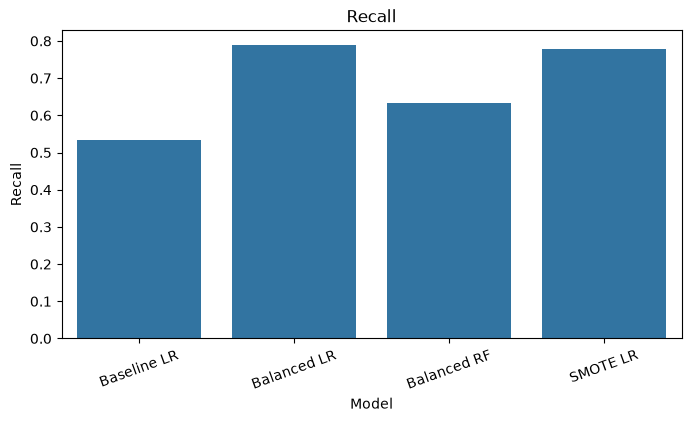

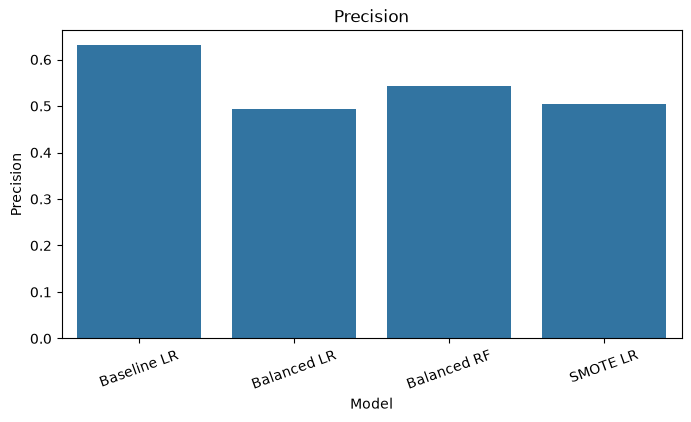

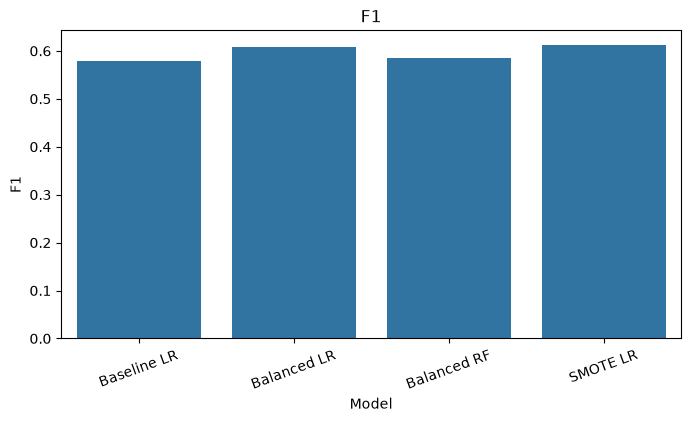

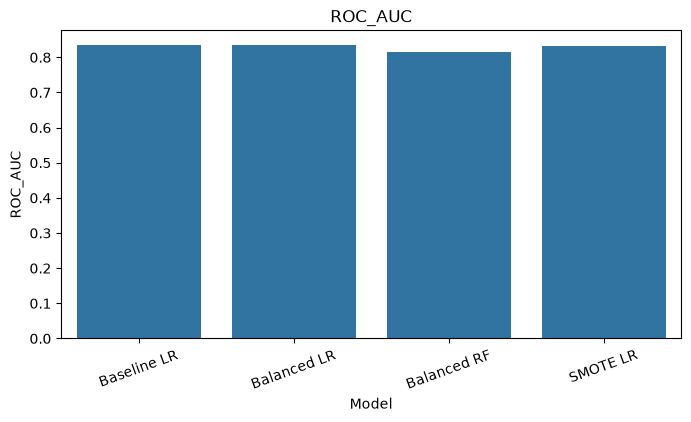

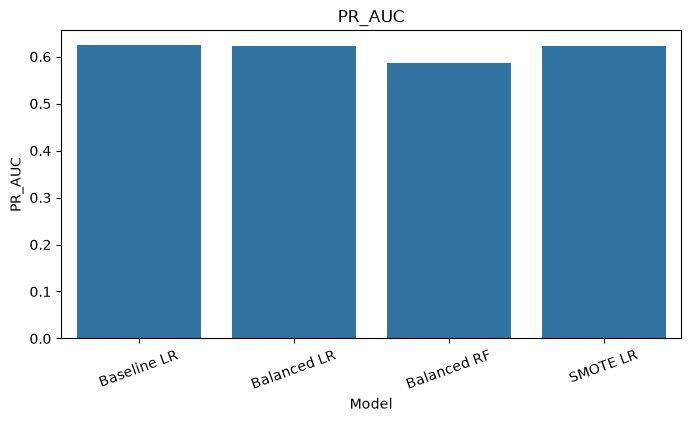

In [17]:
import seaborn as sns

metrics = [
    "Recall",
    "Precision",
    "F1",
    "ROC_AUC",
    "PR_AUC"
]

for metric in metrics:

    plt.figure(figsize=(8,4))

    sns.barplot(
        data=results,
        x="Model",
        y=metric
    )

    plt.title(metric)

    plt.xticks(rotation=20)

    plt.show()

## Interpretation of Results

Three imbalance handling strategies were compared:

- Baseline Logistic Regression
- Cost-Sensitive Logistic Regression
- SMOTE Logistic Regression

### Baseline Logistic Regression

The baseline model achieved the highest Accuracy and Precision but identified only 53.5% of customers who churned.

### Cost-Sensitive Logistic Regression

Applying class weights substantially improved Recall from 53.5% to 78.9%, indicating that the model identified many more customers likely to churn. Although Precision and Accuracy decreased, the model became much more effective at detecting the minority class.

### SMOTE Logistic Regression

SMOTE produced very similar performance to Cost-Sensitive Learning. It achieved the highest F1-score and slightly higher Precision, while Cost-Sensitive Learning achieved marginally higher Recall and ROC-AUC.

### Balanced Random Forest

Balanced Random Forest underperformed both Logistic Regression approaches across most evaluation metrics and was therefore not selected for further experimentation.

# Save the model

In [19]:
import joblib

joblib.dump(
    balanced_lr_pipeline,
    "../models/balanced_logistic_regression.pkl"
)

['../models/balanced_logistic_regression.pkl']

In [20]:
best_cost_sensitive_model = balanced_lr_pipeline

## Conclusion

Cost-Sensitive Learning proved to be a highly effective alternative to SMOTE.

Both approaches significantly improved Recall compared to the baseline Logistic Regression model while maintaining comparable ROC-AUC and PR-AUC values.

SMOTE achieved the highest F1-score, whereas Cost-Sensitive Logistic Regression achieved slightly higher Recall and ROC-AUC without generating synthetic training samples.

These findings suggest that Cost-Sensitive Learning can serve as a practical alternative when synthetic data generation is undesirable.